In [67]:
import numpy as np
import pandas as pd
import tensorflow
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import griddata
import unittest
import math
from scipy.stats import mvn

# 1. Import raw data

In [68]:
df = pd.read_csv(r"C:\Users\victo\Downloads\spy_2020_2022.csv", low_memory=False)

# 2. Clean data

In [69]:
df.columns = df.columns.str.strip().str.strip('[]')
df = df.drop(['QUOTE_UNIXTIME', 'QUOTE_READTIME', 'QUOTE_TIME_HOURS', 'EXPIRE_UNIX', 'C_DELTA', 'C_GAMMA', 'C_VEGA', 'C_THETA', 'C_RHO', 'P_DELTA', 'P_GAMMA', 'P_VEGA', 'P_THETA', 'P_RHO'], axis=1)
df = df.applymap(lambda x: x.lstrip() if isinstance(x, str) else x)
df['EXPIRE_DATE'] = pd.to_datetime(df['EXPIRE_DATE'], errors='coerce')
df['QUOTE_DATE'] = pd.to_datetime(df['QUOTE_DATE'], errors='coerce')
date_cols = ['EXPIRE_DATE', 'QUOTE_DATE']
cols_to_exclude = ['EXPIRE_DATE', 'QUOTE_DATE', 'C_SIZE', 'P_SIZE']
num_cols = df.columns.difference(cols_to_exclude)
df[date_cols] = df[date_cols].apply(pd.to_datetime, format='%Y-%m-%d', errors='coerce')
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df = df.drop(['C_IV', 'C_VOLUME', 'C_LAST', 'C_SIZE', 'C_BID', 'C_ASK', 'STRIKE_DISTANCE', 'STRIKE_DISTANCE_PCT', 'EXPIRE_DATE'], axis=1)
df['moneyness'] = df['UNDERLYING_LAST'] / df['STRIKE']
df = df[df['moneyness'] > 0.5]  # filter out moneyness <= 0.5
df = df[df['moneyness'] < 1.5]  # filter out moneyness >= 1.5
df = df[df['P_BID'] > 0]  # filter out 0 bid options
df['midprice'] = (df['P_BID'] + df['P_ASK']) / 2.0
df = df[df['midprice'] > 1] 
df = df[df['DTE'] > 0]  # filter out 0DTE options
df = df[df['P_VOLUME'] > 0] # filter out 0 volume options
df = df[df['P_IV'] < 3] # filter out extreme IV values
df = df[df['P_IV'] > 0.05] # filter out extreme IV values
df['T'] = df['DTE'] / 365.0

C:\Users\victo\AppData\Local\Temp\ipykernel_22372\23175362.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.lstrip() if isinstance(x, str) else x)


# 3. Add additional data and clean

In [70]:
df['log_moneyness'] = np.log(df['moneyness'])
df['q'] = 0.015  # constant dividend yield
rf = pd.read_csv(r"C:\Users\victo\Downloads\DTB3.csv", low_memory=False)
rf['observation_date'] = pd.to_datetime(rf['observation_date'], format='%Y-%m-%d', errors='coerce')
rf.rename(columns={'observation_date': 'date', 'DTB3': 'risk_free_rate'}, inplace=True)
rf['risk_free_rate'] /= 100
rf.sort_values('date', inplace=True)
rf.fillna(method='ffill', inplace=True)
df.rename(columns={'QUOTE_DATE': 'date'}, inplace=True)
df = df.merge(rf, on='date', how='left')

C:\Users\victo\AppData\Local\Temp\ipykernel_22372\3430148834.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rf.fillna(method='ffill', inplace=True)


# 4. Define Black-Scholes implied volatility

In [71]:
from scipy.optimize import brentq, newton
def black_scholes_put_price(S, K, T, r, sigma):
    """Black-Scholes formula for European put option."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

def implied_volatility_put(market_price, S, K, T, r, 
                           initial_guess=0.2, 
                           tol=1e-6, 
                           max_iter=100):
    """Compute implied volatility using the Newton-Raphson method, with fallback."""
    
    def objective(sigma):
        return black_scholes_put_price(S, K, T, r, sigma) - market_price

    try:
        # Try Newton-Raphson with derivative
        iv = newton(objective, initial_guess, tol=tol, maxiter=max_iter)
    except (RuntimeError, OverflowError):
        # Fallback to Brent's method if Newton-Raphson fails
        iv = brentq(objective, 1e-6, 5.0, xtol=tol)
    return iv

# 5. Get correct BS implied vol from market prices

In [72]:
def compute_iv(row):
    try:
        iv = implied_volatility_put(row['midprice'], row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], initial_guess=0.2, tol=1e-3, max_iter=100)
    except Exception as e:
        iv = np.nan
    return iv
df['implied_volatility'] = df.apply(compute_iv, axis=1)

In [73]:
# df must contain: a Date column and a Price column
# 1.  Make sure the date column is a datetime index with one row per date
vol_df = (
    df                                   # your original dataframe
    .assign(Date=pd.to_datetime(df['date']))
    .groupby('date', as_index=False)     # collapse any duplicate rows per date
    .agg({'UNDERLYING_LAST': 'first'})             # or 'mean' / 'last' – your choice
    .sort_values('date')
    .set_index('date')
)

# 2.  Compute daily log-returns
vol_df['log_ret'] = np.log(vol_df['UNDERLYING_LAST'] / vol_df['UNDERLYING_LAST'].shift(1))

# 3.  20-day rolling *daily* volatility (σ20)
vol_df['vol_20d'] = vol_df['log_ret'].rolling(window=20).std(ddof=0)      # population stdev

# 4.  Scale to annual volatility  (√252 ≈ trading days in a year)
vol_df['vol_20d_annual'] = vol_df['vol_20d'] * np.sqrt(252)




In [74]:
vol_df = vol_df.reset_index().rename(columns={'index': 'date'})
df = df.merge(vol_df[['date', 'vol_20d_annual']], on='date', how='left')


In [75]:
df['vol_20d_annual'].fillna(0.20, inplace=True)

C:\Users\victo\AppData\Local\Temp\ipykernel_22372\713945868.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['vol_20d_annual'].fillna(0.20, inplace=True)


In [76]:
df.sort_values(by=['vol_20d_annual'], ascending=True, inplace=True)
df.head()

,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,moneyness,midprice,T,log_moneyness,q,risk_free_rate,implied_volatility,vol_20d_annual
1129111,2021-11-24,469.44,113.96,371.0,3.16,3.18,204 x 150,3.43,0.31406,9.0,1.265337,3.170,0.312219,0.235338,0.015,0.0006,0.317530,0.062803
1128699,2021-11-24,469.44,28.00,468.0,7.11,7.28,76 x 39,7.58,0.14177,38.0,1.003077,7.195,0.076712,0.003072,0.015,0.0006,0.152633,0.062803
1128698,2021-11-24,469.44,28.00,466.0,6.43,6.60,126 x 76,6.93,0.14707,21.0,1.007382,6.515,0.076712,0.007355,0.015,0.0006,0.157304,0.062803
1128697,2021-11-24,469.44,28.00,465.0,6.13,6.29,78 x 48,6.25,0.14928,67.0,1.009548,6.210,0.076712,0.009503,0.015,0.0006,0.159813,0.062803
1128696,2021-11-24,469.44,28.00,464.0,5.90,5.97,25 x 25,6.39,0.15215,113.0,1.011724,5.935,0.076712,0.011656,0.015,0.0006,0.162598,0.062803


# 6. Split data

In [77]:
# Sort by date
df = df.sort_values('date')

# Determine cutoff date (e.g., 80% point)
cutoff_date = df['date'].quantile(0.8)

# Create splits
train_df = df[df['date'] <= cutoff_date]
test_df = df[df['date'] > cutoff_date]

# 7. Define Bjerklund-Stensland model

In [78]:
def _phi(fs, t, gamma, h, i, r, b, v):
    d1 = -(math.log(fs / h) + (b + (gamma - 0.5) * (v ** 2)) * t) / (v * math.sqrt(t))
    d2 = d1 - 2 * math.log(i / fs) / (v * math.sqrt(t))

    lambda1 = (-r + gamma * b + 0.5 * gamma * (gamma - 1) * (v ** 2))
    kappa = (2 * b) / (v ** 2) + (2 * gamma - 1)

    phi = math.exp(lambda1 * t) * (fs ** gamma) * (norm.cdf(d1) - ((i / fs) ** kappa) * norm.cdf(d2))
    return phi

def _cbnd(a, b, rho):
    # This distribution uses the Genz multi-variate normal distribution 
    # code found as part of the standard SciPy distribution
    lower = np.array([0, 0])
    upper = np.array([a, b])
    infin = np.array([0, 0])
    correl = rho
    error, value, inform = mvn.mvndst(lower, upper, infin, correl)
    return value


def _psi(fs, t2, gamma, h, i2, i1, t1, r, b, v):
    vsqrt_t1 = v * math.sqrt(t1)
    vsqrt_t2 = v * math.sqrt(t2)

    bgamma_t1 = (b + (gamma - 0.5) * (v ** 2)) * t1
    bgamma_t2 = (b + (gamma - 0.5) * (v ** 2)) * t2

    d1 = (math.log(fs / i1) + bgamma_t1) / vsqrt_t1
    d3 = (math.log(fs / i1) - bgamma_t1) / vsqrt_t1

    d2 = (math.log((i2 ** 2) / (fs * i1)) + bgamma_t1) / vsqrt_t1
    d4 = (math.log((i2 ** 2) / (fs * i1)) - bgamma_t1) / vsqrt_t1

    e1 = (math.log(fs / h) + bgamma_t2) / vsqrt_t2
    e2 = (math.log((i2 ** 2) / (fs * h)) + bgamma_t2) / vsqrt_t2
    e3 = (math.log((i1 ** 2) / (fs * h)) + bgamma_t2) / vsqrt_t2
    e4 = (math.log((fs * (i1 ** 2)) / (h * (i2 ** 2))) + bgamma_t2) / vsqrt_t2

    tau = math.sqrt(t1 / t2)
    lambda1 = (-r + gamma * b + 0.5 * gamma * (gamma - 1) * (v ** 2))
    kappa = (2 * b) / (v ** 2) + (2 * gamma - 1)

    psi = math.exp(lambda1 * t2) * (fs ** gamma) * (_cbnd(-d1, -e1, tau)
                                                    - ((i2 / fs) ** kappa) * _cbnd(-d2, -e2, tau)
                                                    - ((i1 / fs) ** kappa) * _cbnd(-d3, -e3, -tau)
                                                    + ((i1 / i2) ** kappa) * _cbnd(-d4, -e4, -tau))
    return psi


def _bjerksund_stensland_2002(fs, x, t, r, b, v):
    # preliminary calculations
    v2 = v ** 2
    t1 = 0.5 * (math.sqrt(5) - 1) * t
    t2 = t

    beta_inside = ((b / v2 - 0.5) ** 2) + 2 * r / v2
    # forcing the inside of the sqrt to be a positive number
    beta_inside = abs(beta_inside)
    beta = (0.5 - b / v2) + math.sqrt(beta_inside)
    b_infinity = (beta / (beta - 1)) * x
    b_zero = max(x, (r / (r - b)) * x)

    h1 = -(b * t1 + 2 * v * math.sqrt(t1)) * ((x ** 2) / ((b_infinity - b_zero) * b_zero))
    h2 = -(b * t2 + 2 * v * math.sqrt(t2)) * ((x ** 2) / ((b_infinity - b_zero) * b_zero))

    i1 = b_zero + (b_infinity - b_zero) * (1 - math.exp(h1))
    i2 = b_zero + (b_infinity - b_zero) * (1 - math.exp(h2))

    alpha1 = (i1 - x) * (i1 ** (-beta))
    alpha2 = (i2 - x) * (i2 ** (-beta))

    # check for immediate exercise
    if fs >= i2:
        value = fs - x
    else:
        # Perform the main calculation    
        value = (alpha2 * (fs ** beta)
                 - alpha2 * _phi(fs, t1, beta, i2, i2, r, b, v)
                 + _phi(fs, t1, 1, i2, i2, r, b, v)
                 - _phi(fs, t1, 1, i1, i2, r, b, v)
                 - x * _phi(fs, t1, 0, i2, i2, r, b, v)
                 + x * _phi(fs, t1, 0, i1, i2, r, b, v)
                 + alpha1 * _phi(fs, t1, beta, i1, i2, r, b, v)
                 - alpha1 * _psi(fs, t2, beta, i1, i2, i1, t1, r, b, v)
                 + _psi(fs, t2, 1, i1, i2, i1, t1, r, b, v)
                 - _psi(fs, t2, 1, x, i2, i1, t1, r, b, v)
                 - x * _psi(fs, t2, 0, i1, i2, i1, t1, r, b, v)
                 + x * _psi(fs, t2, 0, x, i2, i1, t1, r, b, v))

        
    return value

def BS2002(type, fs, x, t, r, b, v):
    if type == 'c':
        return _bjerksund_stensland_2002(fs, x, t, r, b, v)
    elif type == 'p':
        put__x = fs
        put_fs = x
        put_b = -b
        put_r = r - b
        return _bjerksund_stensland_2002(put_fs, put__x, t, put_r, put_b, v)

# Longstaff-Schwartz

In [79]:
import numpy as np

def price_american_put_LSM(S0, K, T, r, q, sigma, num_paths, num_steps):
    """
    Price an American put option using Longstaff-Schwartz Least Squares Monte Carlo.
    
    Parameters:
        S0 (float)      : Initial stock price
        K (float)       : Strike price of the put
        T (float)       : Time to expiration in years
        r (float)       : Risk-free interest rate (annual continuously compounded)
        q (float)       : Continuous dividend yield of the stock
        sigma (float)   : Volatility of the stock (annual standard deviation)
        num_paths (int) : Number of Monte Carlo simulation paths
        num_steps (int) : Number of time steps (discrete exercise opportunities)
    
    Returns:
        float: Estimated American put option price.
    """
    # Time increment
    dt = T / num_steps
    # Pre-compute drift and volatility factors for efficiency
    drift = (r - q - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)
    
    # 1. Simulate risk-neutral GBM paths for the underlying stock
    # Initialize array for stock paths: dimensions (num_steps+1) x (num_paths)
    S_paths = np.empty((num_steps+1, num_paths))
    S_paths[0, :] = S0
    # Generate all random shocks at once for efficiency
    # Each step has num_paths independent N(0,1) draws
    Z = np.random.normal(size=(num_steps, num_paths))
    for t in range(1, num_steps+1):
        # Vectorized stock price update: S[t] = S[t-1] * exp(drift + vol * Z)
        S_paths[t, :] = S_paths[t-1, :] * np.exp(drift + vol * Z[t-1, :])
    
    # 2. Compute payoff at maturity for all paths (time index num_steps)
    # For a put option, payoff = max(K - S, 0)
    payoffs = np.maximum(K - S_paths[num_steps, :], 0.0)
    
    # 3. Backward induction to incorporate early exercise opportunities
    # We'll use an array `cashflows` to track the optimal payoff (discounted) from each path
    cashflows = payoffs.copy()  # start with terminal payoff at T for each path
    # Work backward from second-last time step down to first time step
    for t in range(num_steps-1, 0, -1):
        # Discount the cashflows from the next time step back to time t
        cashflows *= np.exp(-r * dt)
        # Get stock prices at time t
        S_t = S_paths[t, :]
        # Identify paths where option is in the money at time t (put: S_t < K)
        in_the_money = S_t < K
        if not np.any(in_the_money):
            # If no path is in the money, move to the previous time step
            continue
        
        # Prepare regression to estimate continuation value: 
        X = S_t[in_the_money]  # stock prices for in-the-money paths
        Y = cashflows[in_the_money]  # discounted future cashflows for those paths
        
        # Construct Laguerre polynomial basis:
        # We'll use [1, L1(x), L2(x)] where L1(x) = 1 - x, L2(x) = 1 - 2x + 0.5*x^2.
        # (Optionally, x could be scaled like x = S_t/K to improve numerical stability)
        x = X  # using X directly; could also use X/K for normalization
        L0 = np.ones_like(x)
        L1 = 1.0 - x
        L2 = 1.0 - 2.0*x + 0.5 * x**2
        # Design matrix for regression (shape: n_paths_in_money x 3)
        A = np.vstack([L0, L1, L2]).T
        
        # Solve least-squares regression A * beta ≈ Y to get regression coefficients
        beta, *_ = np.linalg.lstsq(A, Y, rcond=None)
        # Estimated continuation value for all in-the-money paths at time t
        C_hat = beta[0] + beta[1]*(1.0 - S_t) + beta[2]*(1.0 - 2.0*S_t + 0.5*S_t**2)
        
        # Decide whether to exercise or continue for in-the-money paths
        exercise_value = np.maximum(K - S_t, 0.0)  # immediate payoff if exercised at t
        # If exercise value is greater than continuation estimate, exercise (replace cashflow)
        exercise_indices = in_the_money & (exercise_value > C_hat)
        cashflows[exercise_indices] = exercise_value[exercise_indices]
        # Paths not meeting the condition will keep their future cashflow (already in `cashflows`)
    # end for loop
    
    # 4. At time 0, the price is the average of discounted cashflows (already at t=0 after loop)
    option_price = np.exp(-r * dt) * np.mean(cashflows)  # discount from t=1 to t=0 and average
    return option_price


In [80]:
price_american_put_LSM(S0=40, K=40, T=1.0, r=0.06, q=0, sigma=0.2, num_paths=10000, num_steps=1000)

2.3297451271943297

In [124]:
target_date = pd.to_datetime('2021-09-01')
LSM_df = df[df['date'] == target_date].copy()

LSM_df['LSM_price_rolling_vol'] = LSM_df.apply(lambda row: price_american_put_LSM(row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, row['vol_20d_annual'], num_paths=10000, num_steps=1000), axis=1)


In [129]:
LSM_df['LSM_price_const_vol'] = LSM_df.apply(lambda row: price_american_put_LSM(row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, 0.2, num_paths=10000, num_steps=1000), axis=1)


In [126]:
target_date_tst = pd.to_datetime('2020-09-01')
LSM_df_tst = df[df['date'] == target_date_tst].copy()
LSM_df_tst['LSM_price_rolling_vol'] = LSM_df_tst.apply(lambda row: price_american_put_LSM(row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, row['vol_20d_annual'], num_paths=10000, num_steps=1000), axis=1)
LSM_df_tst['LSM_price_const_vol'] = LSM_df_tst.apply(lambda row: price_american_put_LSM(row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, 0.2, num_paths=10000, num_steps=1000), axis=1)


In [134]:
LSM_df['const_vol_diff'] = LSM_df['LSM_price_const_vol'] - LSM_df['midprice']
LSM_df['rolling_vol_diff'] = LSM_df['LSM_price_rolling_vol'] - LSM_df['midprice']

In [138]:
LSM_df.sort_values(by=['rolling_vol_diff'], ascending=True, inplace=True)
LSM_df.head()

,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,...,T,log_moneyness,q,risk_free_rate,implied_volatility,vol_20d_annual,LSM_price_rolling_vol,LSM_price_const_vol,const_vol_diff,rolling_vol_diff
1889,2021-09-01,451.85,835.04,415.0,39.36,43.50,36 x 26,40.99,0.21391,1.0,...,2.287781,0.085072,0.015,0.0005,0.223847,0.076577,10.431531,39.783792,-1.646208,-30.998469
1887,2021-09-01,451.85,835.04,405.0,36.21,40.00,38 x 26,38.25,0.21925,10.0,...,2.287781,0.109463,0.015,0.0005,0.228767,0.076577,7.203122,35.976518,-2.128482,-30.901878
1888,2021-09-01,451.85,835.04,410.0,37.75,42.00,55 x 26,39.60,0.21718,3.0,...,2.287781,0.097193,0.015,0.0005,0.226849,0.076577,9.003234,37.440449,-2.434551,-30.871766
1886,2021-09-01,451.85,835.04,400.0,34.74,37.95,38 x 1,35.40,0.22153,7.0,...,2.287781,0.121886,0.015,0.0005,0.230498,0.076577,5.951495,34.165336,-2.179664,-30.393505
1885,2021-09-01,451.85,835.04,395.0,33.26,37.00,52 x 26,34.05,0.22500,2.0,...,2.287781,0.134465,0.015,0.0005,0.234330,0.076577,4.756054,31.400108,-3.729892,-30.373946


In [132]:
# Errors
abs_error_sum_const_vol = 0
rmse_sum_const_vol = 0
rel_error_sum_const_vol = 0
for i in range(len(LSM_df)):
    abs_error_sum_const_vol += np.abs(LSM_df['LSM_price_const_vol'].iloc[i] - LSM_df['midprice'].iloc[i])
    rmse_sum_const_vol += (LSM_df['LSM_price_const_vol'].iloc[i] - LSM_df['midprice'].iloc[i])**2
    rel_error_sum_const_vol += np.abs((LSM_df['LSM_price_const_vol'].iloc[i] - LSM_df['midprice'].iloc[i]) / np.abs(LSM_df['midprice'].iloc[i]))

# Metrics
mae_const_vol = abs_error_sum_const_vol / len(LSM_df)
rmse_const_vol = np.sqrt(rmse_sum_const_vol / len(LSM_df))
rel_error_const_vol = rel_error_sum_const_vol / len(LSM_df)
re_sum_const_vol = rel_error_sum_const_vol


print(f"MAE: {mae_const_vol:.4f}")
print(f"RMSE: {rmse_const_vol:.4f}")
print(f"Sum of RE: {re_sum_const_vol:.4f}")
print(f"Mean RE: {rel_error_const_vol:.4f}")

MAE: 2.8874
RMSE: 3.6590
Sum of RE: 759.1690
Mean RE: 0.3973


In [142]:
# Errors
abs_error_sum_const_vol = 0
rmse_sum_const_vol = 0
rel_error_sum_const_vol = 0
for i in range(len(LSM_df_tst)):
    abs_error_sum_const_vol += np.abs(LSM_df_tst['LSM_price_const_vol'].iloc[i] - LSM_df_tst['midprice'].iloc[i])
    rmse_sum_const_vol += (LSM_df_tst['LSM_price_const_vol'].iloc[i] - LSM_df_tst['midprice'].iloc[i])**2
    rel_error_sum_const_vol += np.abs((LSM_df_tst['LSM_price_const_vol'].iloc[i] - LSM_df_tst['midprice'].iloc[i]) / np.abs(LSM_df_tst['midprice'].iloc[i]))

# Metrics
mae_const_vol = abs_error_sum_const_vol / len(LSM_df_tst)
rmse_const_vol = np.sqrt(rmse_sum_const_vol / len(LSM_df_tst))
rel_error_const_vol = rel_error_sum_const_vol / len(LSM_df_tst)
re_sum_const_vol = rel_error_sum_const_vol


print(f"MAE: {mae_const_vol:.4f}")
print(f"RMSE: {rmse_const_vol:.4f}")
print(f"Sum of RE: {re_sum_const_vol:.4f}")
print(f"Mean RE: {rel_error_const_vol:.4f}")

MAE: 3.8673
RMSE: 4.9854
Sum of RE: 859.8979
Mean RE: 0.4488


# 8. Apply Bjerksund-Stensland model

In [84]:
test_df['Bjerksund_Stensland_price_const_vol'] = test_df.apply(lambda row: BS2002('p', row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, 0.2), axis=1)
train_df['Bjerksund_Stensland_price_const_vol'] = train_df.apply(lambda row: BS2002('p', row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, 0.2), axis=1)
test_df['Bjerksund_Stensland_price_rolling_vol'] = test_df.apply(lambda row: BS2002('p', row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, row['vol_20d_annual']), axis=1)
train_df['Bjerksund_Stensland_price_rolling_vol'] = train_df.apply(lambda row: BS2002('p', row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, row['vol_20d_annual']), axis=1)

C:\Users\victo\AppData\Local\Temp\ipykernel_22372\2514774326.py:18: DeprecationWarning: `scipy.stats.mvn.mvndst` is deprecated along with the `scipy.stats.mvn` namespace. `scipy.stats.mvn.mvndst` will be removed in SciPy 1.14.0, and the `scipy.stats.mvn` namespace will be removed in SciPy 2.0.0.
  error, value, inform = mvn.mvndst(lower, upper, infin, correl)
C:\Users\victo\AppData\Local\Temp\ipykernel_22372\2018533111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Bjerksund_Stensland_price_const_vol'] = test_df.apply(lambda row: BS2002('p', row['UNDERLYING_LAST'], row['STRIKE'], row['T'], row['risk_free_rate'], 0.015, 0.2), axis=1)
C:\Users\victo\AppData\Local\Temp\ipykernel_22372\2514774326.py:18: DeprecationWarning: `scipy.stats.

# 9. Calculate error metrics

In [85]:
df = df.dropna()
test_df = test_df.dropna()
train_df = train_df.dropna()

## Constant vol

In [86]:
# Errors
abs_error_sum_const_vol = 0
rmse_sum_const_vol = 0
rel_error_sum_const_vol = 0
for i in range(len(test_df)):
    abs_error_sum_const_vol += np.abs(test_df['Bjerksund_Stensland_price_const_vol'].iloc[i] - test_df['midprice'].iloc[i])
    rmse_sum_const_vol += (test_df['Bjerksund_Stensland_price_const_vol'].iloc[i] - test_df['midprice'].iloc[i])**2
    rel_error_sum_const_vol += np.abs((test_df['Bjerksund_Stensland_price_const_vol'].iloc[i] - test_df['midprice'].iloc[i]) / np.abs(test_df['midprice'].iloc[i]))

# Metrics
mae_const_vol = abs_error_sum_const_vol / len(test_df)
rmse_const_vol = np.sqrt(rmse_sum_const_vol / len(test_df))
rel_error_const_vol = rel_error_sum_const_vol / len(test_df)
re_sum_const_vol = rel_error_sum_const_vol


print(f"MAE: {mae_const_vol:.4f}")
print(f"RMSE: {rmse_const_vol:.4f}")
print(f"Sum of RE: {re_sum_const_vol:.4f}")
print(f"Mean RE: {rel_error_const_vol:.4f}")

MAE: 2.6697
RMSE: 3.5272
Sum of RE: 99006.6125
Mean RE: 0.3675


In [87]:
# Errors
abs_error_sum_const_vol = 0
rmse_sum_const_vol = 0
rel_error_sum_const_vol = 0
for i in range(len(train_df)):
    abs_error_sum_const_vol += np.abs(train_df['Bjerksund_Stensland_price_const_vol'].iloc[i] - train_df['midprice'].iloc[i])
    rmse_sum_const_vol += (train_df['Bjerksund_Stensland_price_const_vol'].iloc[i] - train_df['midprice'].iloc[i])**2
    rel_error_sum_const_vol += np.abs((train_df['Bjerksund_Stensland_price_const_vol'].iloc[i] - train_df['midprice'].iloc[i]) / np.abs(train_df['midprice'].iloc[i]))

# Metrics
mae_const_vol = abs_error_sum_const_vol / len(train_df)
rmse_const_vol = np.sqrt(rmse_sum_const_vol / len(train_df))
rel_error_const_vol = rel_error_sum_const_vol / len(train_df)
re_sum_const_vol = rel_error_sum_const_vol


print(f"MAE: {mae_const_vol:.4f}")
print(f"RMSE: {rmse_const_vol:.4f}")
print(f"Sum of RE: {re_sum_const_vol:.4f}")
print(f"Mean RE: {rel_error_const_vol:.4f}")

MAE: 3.8056
RMSE: 5.1004
Sum of RE: 438170.1364
Mean RE: 0.4050


## Rolling vol

In [88]:
# Errors
abs_error_sum_rolling_vol = 0
rmse_sum_rolling_vol = 0
rel_error_sum_rolling_vol = 0
for i in range(len(train_df)):
    abs_error_sum_rolling_vol += np.abs(train_df['Bjerksund_Stensland_price_rolling_vol'].iloc[i] - train_df['midprice'].iloc[i])
    rmse_sum_rolling_vol += (train_df['Bjerksund_Stensland_price_rolling_vol'].iloc[i] - train_df['midprice'].iloc[i])**2
    rel_error_sum_rolling_vol += np.abs((train_df['Bjerksund_Stensland_price_rolling_vol'].iloc[i] - train_df['midprice'].iloc[i]) / np.abs(train_df['midprice'].iloc[i]))

# Metrics
mae_rolling_vol = abs_error_sum_rolling_vol / len(train_df)
rmse_rolling_vol = np.sqrt(rmse_sum_rolling_vol / len(train_df))
rel_error_rolling_vol = rel_error_sum_rolling_vol / len(train_df)
re_sum_rolling_vol = rel_error_sum_rolling_vol


print(f"MAE: {mae_rolling_vol:.4f}")
print(f"RMSE: {rmse_rolling_vol:.4f}")
print(f"Sum of RE: {re_sum_rolling_vol:.4f}")
print(f"Mean RE: {rel_error_rolling_vol:.4f}")

MAE: 6.6350
RMSE: 11.1343
Sum of RE: 589090.0654
Mean RE: 0.5445


In [89]:
# Errors
abs_error_sum_rolling_vol = 0
rmse_sum_rolling_vol = 0
rel_error_sum_rolling_vol = 0
for i in range(len(test_df)):
    abs_error_sum_rolling_vol += np.abs(test_df['Bjerksund_Stensland_price_rolling_vol'].iloc[i] - test_df['midprice'].iloc[i])
    rmse_sum_rolling_vol += (test_df['Bjerksund_Stensland_price_rolling_vol'].iloc[i] - test_df['midprice'].iloc[i])**2
    rel_error_sum_rolling_vol += np.abs((test_df['Bjerksund_Stensland_price_rolling_vol'].iloc[i] - test_df['midprice'].iloc[i]) / np.abs(test_df['midprice'].iloc[i]))

# Metrics
mae_rolling_vol = abs_error_sum_rolling_vol / len(test_df)
rmse_rolling_vol = np.sqrt(rmse_sum_rolling_vol / len(test_df))
rel_error_rolling_vol = rel_error_sum_rolling_vol / len(test_df)
re_sum_rolling_vol = rel_error_sum_rolling_vol


print(f"MAE: {mae_rolling_vol:.4f}")
print(f"RMSE: {rmse_rolling_vol:.4f}")
print(f"Sum of RE: {re_sum_rolling_vol:.4f}")
print(f"Mean RE: {rel_error_rolling_vol:.4f}")

MAE: 2.3252
RMSE: 3.5344
Sum of RE: 77666.6171
Mean RE: 0.2883


# IV error

In [90]:
# Errors
abs_error_sum_rolling_vol = 0
rmse_sum_rolling_vol = 0
rel_error_sum_rolling_vol = 0
for i in range(len(test_df)):
    abs_error_sum_rolling_vol += np.abs(0.2 - test_df['P_IV'].iloc[i])
    rmse_sum_rolling_vol += (0.2 - test_df['P_IV'].iloc[i])**2
    rel_error_sum_rolling_vol += np.abs((0.2 - test_df['P_IV'].iloc[i]) / np.abs(test_df['P_IV'].iloc[i]))

# Metrics
mae_rolling_vol = abs_error_sum_rolling_vol / len(test_df)
rmse_rolling_vol = np.sqrt(rmse_sum_rolling_vol / len(test_df))
rel_error_rolling_vol = rel_error_sum_rolling_vol / len(test_df)
re_sum_rolling_vol = rel_error_sum_rolling_vol


print(f"MAE: {mae_rolling_vol:.4f}")
print(f"RMSE: {rmse_rolling_vol:.4f}")
print(f"Sum of RE: {re_sum_rolling_vol:.4f}")
print(f"Mean RE: {rel_error_rolling_vol:.4f}")

MAE: 0.0691
RMSE: 0.0949
Sum of RE: 64070.4068
Mean RE: 0.2378


In [91]:
# Errors
abs_error_sum_rolling_vol = 0
rmse_sum_rolling_vol = 0
rel_error_sum_rolling_vol = 0
for i in range(len(test_df)):
    abs_error_sum_rolling_vol += np.abs(test_df['vol_20d_annual'].iloc[i] - test_df['P_IV'].iloc[i])
    rmse_sum_rolling_vol += (test_df['vol_20d_annual'].iloc[i] - test_df['P_IV'].iloc[i])**2
    rel_error_sum_rolling_vol += np.abs((test_df['vol_20d_annual'].iloc[i] - test_df['P_IV'].iloc[i]) / np.abs(test_df['P_IV'].iloc[i]))

# Metrics
mae_rolling_vol = abs_error_sum_rolling_vol / len(test_df)
rmse_rolling_vol = np.sqrt(rmse_sum_rolling_vol / len(test_df))
rel_error_rolling_vol = rel_error_sum_rolling_vol / len(test_df)
re_sum_rolling_vol = rel_error_sum_rolling_vol


print(f"MAE: {mae_rolling_vol:.4f}")
print(f"RMSE: {rmse_rolling_vol:.4f}")
print(f"Sum of RE: {re_sum_rolling_vol:.4f}")
print(f"Mean RE: {rel_error_rolling_vol:.4f}")

MAE: 0.0550
RMSE: 0.0812
Sum of RE: 54715.9369
Mean RE: 0.2031


In [92]:
train_df.sort_values(by=['P_IV'], ascending=True, inplace=True)
train_df.head()

,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,moneyness,midprice,T,log_moneyness,q,risk_free_rate,implied_volatility,vol_20d_annual,Bjerksund_Stensland_price_const_vol,Bjerksund_Stensland_price_rolling_vol
910990,2020-01-21,331.29,13.0,337.0,5.81,5.95,301 x 272,6.14,0.05004,3.0,0.983056,5.880,0.035616,-0.017089,0.015,0.0153,0.080344,0.200000,8.284132,8.284132
392034,2020-10-08,343.65,1.0,347.0,3.42,3.47,25 x 25,3.54,0.05008,907.0,0.990346,3.445,0.002740,-0.009701,0.015,0.0009,0.135298,0.190009,3.684910,3.638958
909767,2020-01-17,332.01,10.0,333.0,1.96,1.99,50 x 546,1.90,0.05012,828.0,0.997027,1.975,0.027397,-0.002977,0.015,0.0153,0.068884,0.200000,4.834680,4.834680
898385,2020-01-06,323.68,25.0,333.0,9.43,9.52,163 x 326,10.05,0.05013,71.0,0.972012,9.475,0.068493,-0.028387,0.015,0.0153,0.091932,0.200000,12.288267,12.288267
53790,2021-08-06,442.47,3.0,443.0,1.17,1.21,310 x 150,1.20,0.05016,25694.0,0.998804,1.190,0.008219,-0.001197,0.015,0.0006,0.056321,0.106060,3.447475,1.948599


# 10. Define Neural Network

In [186]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader


class OptionpricingDataset(Dataset):
    def __init__(self, df, scaler=None, fit_scaler=False):
        df = df.copy()
        self.scaler = scaler
        self.features_cols = ['log_moneyness', 'T', 'risk_free_rate', 'q', 'UNDERLYING_LAST', 'STRIKE', 'P_VOLUME', 'vol_20d_annual', 'midprice']
        self.target_col = ['P_IV']
        X = df[self.features_cols].values.astype(np.float32)
        y = df[self.target_col].values.astype(np.float32).reshape(-1, 1)

        # apply scaling
        if scaler is None:
            self.scaler = StandardScaler()
            self.X = self.scaler.fit_transform(X)
        else:
            self.scaler = scaler
            if fit_scaler:
                self.X = self.scaler.fit_transform(X)
            else:
                self.X = self.scaler.transform(X)

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = OptionpricingDataset(train_df, fit_scaler=True)
scaler = train_dataset.scaler  # Save the fitted scaler

test_dataset = OptionpricingDataset(test_df, scaler=scaler, fit_scaler=False)

import torch.nn as nn

class OptionPricingNN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=[40,40,40,40,]):
        super(OptionPricingNN, self).__init__()
        layers = []
        in_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 1))  # Output layer
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def train_model(model, train_dataset, test_dataset, epochs=10, batch_size=128, lr=1e-4):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    def mape_loss(y_pred, y_true, eps=1e-6):
        return torch.mean(torch.abs((y_true - y_pred) / (y_true + eps)))
    class RMSELoss(nn.Module):
        def __init__(self, eps=1e-6):
            super(RMSELoss, self).__init__()
            self.mse = nn.MSELoss()
            self.eps = eps

        def forward(self, y_pred, y_true):
            return torch.sqrt(self.mse(y_pred, y_true) + self.eps)
     #criterion = nn.SmoothL1Loss()  # Use SmoothL1Loss for regression
    criterion = RMSELoss()  # Use RMSE loss for regression

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    def lr_lambda(epoch):
        if epoch < 20:
            return 1.0       # first 20 epochs: 1e-3*1.0 = 1e-3
        elif epoch < 40:
            return 0.1       # next 20 epochs: 1e-3*0.1 = 1e-4
        else:
            return 0.01      # subsequent epochs: 1e-3*0.01 = 1e-5 (example)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
    
        scheduler.step()  # update the learning rate based on the epoch

        avg_train_loss = train_loss / len(train_dataset)

        # Evaluation
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item() * X_batch.size(0)

        avg_test_loss = test_loss / len(test_dataset)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} | Test Loss: {avg_test_loss:.3f}")

    return model

In [189]:
input_dim = len(train_dataset.features_cols)
model = OptionPricingNN(input_dim=input_dim)

# Train model
trained_model = train_model(model, train_dataset, test_dataset, epochs=10)

Epoch 1/10 | Train Loss: 0.039 | Test Loss: 0.099
Epoch 2/10 | Train Loss: 0.024 | Test Loss: 0.108
Epoch 3/10 | Train Loss: 0.021 | Test Loss: 0.112
Epoch 4/10 | Train Loss: 0.020 | Test Loss: 0.127
Epoch 5/10 | Train Loss: 0.019 | Test Loss: 0.125
Epoch 6/10 | Train Loss: 0.019 | Test Loss: 0.113
Epoch 7/10 | Train Loss: 0.018 | Test Loss: 0.108
Epoch 8/10 | Train Loss: 0.018 | Test Loss: 0.113
Epoch 9/10 | Train Loss: 0.017 | Test Loss: 0.112
Epoch 10/10 | Train Loss: 0.017 | Test Loss: 0.106


In [190]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_prediction_table(model, test_dataset, original_df=None, num_rows=10000000):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    X = test_dataset.X.to(device)
    y_true = test_dataset.y.cpu().numpy()
    
    with torch.no_grad():
        y_pred = model(X).cpu().numpy()

    # Compute errors
    abs_error = np.abs(y_true.flatten() - y_pred.flatten())
    rel_error = abs_error / np.maximum(np.abs(y_true.flatten()), 1e-6)

    mae = np.mean(abs_error)
    rmse = np.sqrt(np.mean((y_true.flatten() - y_pred.flatten()) ** 2))
    rel_error_sum = np.sum(rel_error)

    print(f"\nMAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"Sum of Relative Errors: {rel_error_sum:.6f}")

    # Create table
    data = {
        'Actual Price': y_true.flatten(),
        'Predicted Price': y_pred.flatten(),
        'Absolute Error': abs_error,
        'Relative Error': rel_error
    }

    df_result = pd.DataFrame(data)

    # Optionally join original metadata
    if original_df is not None:
        original_df = original_df.reset_index(drop=True)
        df_result = pd.concat([original_df.reset_index(drop=True), df_result], axis=1)

    return df_result.head(num_rows)

prediction_table = get_prediction_table(trained_model, test_dataset, original_df=test_df)




MAE: 0.096700
RMSE: 0.121126
Sum of Relative Errors: 101943.273438


In [191]:
prediction_table = get_prediction_table(trained_model, test_dataset, original_df=test_df)
prediction_table.head()


MAE: 0.096700
RMSE: 0.121126
Sum of Relative Errors: 101943.273438


,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,...,q,risk_free_rate,implied_volatility,vol_20d_annual,Bjerksund_Stensland_price_const_vol,Bjerksund_Stensland_price_rolling_vol,Actual Price,Predicted Price,Absolute Error,Relative Error
0,2022-02-28,436.52,4.0,434.0,4.61,4.66,11 x 53,4.65,0.28990,5890.0,...,0.015,0.0037,0.319967,0.211713,2.486745,2.691694,0.28990,0.256765,0.033135,0.114300
1,2022-02-28,436.52,9.0,406.0,1.29,1.32,147 x 268,2.09,0.35989,190.0,...,0.015,0.0037,0.375381,0.211713,0.045692,0.070098,0.35989,0.347629,0.012261,0.034068
2,2022-02-28,436.52,9.0,405.0,1.23,1.25,50 x 188,1.48,0.36393,140.0,...,0.015,0.0037,0.379257,0.211713,0.036118,0.056591,0.36393,0.353049,0.010881,0.029900
3,2022-02-28,436.52,9.0,404.0,1.12,1.18,104 x 128,1.38,0.36485,5.0,...,0.015,0.0037,0.380629,0.211713,0.028384,0.045451,0.36485,0.356732,0.008118,0.022250
4,2022-02-28,436.52,9.0,403.0,1.11,1.12,62 x 104,1.62,0.37021,14.0,...,0.015,0.0037,0.386525,0.211713,0.022175,0.036314,0.37021,0.358854,0.011356,0.030676


In [254]:
target_date = pd.to_datetime('2022-03-31')
plot_df = prediction_table[prediction_table['date'] == target_date].copy()
plot_df.head()

,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,...,q,risk_free_rate,implied_volatility,vol_20d_annual,Bjerksund_Stensland_price_const_vol,Bjerksund_Stensland_price_rolling_vol,Actual Price,Predicted Price,Absolute Error,Relative Error
32187,2022-03-31,451.77,91.0,410.0,7.40,7.47,72 x 72,6.60,0.26096,13.0,...,0.015,0.0051,0.263243,0.225072,3.523957,4.892661,0.26096,0.269719,0.008759,0.033566
32188,2022-03-31,451.77,78.0,465.0,20.14,23.70,31 x 1,19.58,0.17140,1739.0,...,0.015,0.0051,0.173927,0.225072,23.537159,25.576202,0.17140,0.187531,0.016131,0.094116
32189,2022-03-31,451.77,91.0,405.0,5.19,6.72,10 x 156,5.56,0.25611,15.0,...,0.015,0.0051,0.257910,0.225072,2.753803,3.964308,0.25611,0.276675,0.020565,0.080298
32190,2022-03-31,451.77,78.0,470.0,23.44,26.55,10 x 1,25.00,0.16654,1275.0,...,0.015,0.0051,0.170051,0.225072,26.801419,28.777179,0.16654,0.184539,0.017999,0.108076
32191,2022-03-31,451.77,91.0,420.0,9.14,9.23,56 x 56,8.18,0.24703,11.0,...,0.015,0.0051,0.249231,0.225072,5.542334,7.218015,0.24703,0.256472,0.009442,0.038224


In [260]:
plot_df = plot_df[plot_df['DTE'] == 91.0].copy()

In [219]:
plot_df.sort_values(by=['P_IV'], ascending=False, inplace=True)
plot_df.head()

,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,...,q,risk_free_rate,implied_volatility,vol_20d_annual,Bjerksund_Stensland_price_const_vol,Bjerksund_Stensland_price_rolling_vol,Actual Price,Predicted Price,Absolute Error,Relative Error
32555,2022-03-31,451.77,91.0,305.0,1.01,1.02,144 x 144,0.90,0.42667,251.0,...,0.015,0.0051,0.428583,0.225072,0.000300,0.002171,0.42667,0.439661,0.012991,0.030448
32334,2022-03-31,451.77,106.0,305.0,1.29,1.31,244 x 1099,1.19,0.41347,15.0,...,0.015,0.0051,0.415473,0.225072,0.001101,0.006296,0.41347,0.422318,0.008848,0.021399
32335,2022-03-31,451.77,106.0,310.0,1.38,1.40,253 x 715,1.27,0.40448,328.0,...,0.015,0.0051,0.405959,0.225072,0.002053,0.010446,0.40448,0.418293,0.013813,0.034151
32704,2022-03-31,451.77,78.0,325.0,1.06,1.08,444 x 951,0.97,0.39981,32.0,...,0.015,0.0051,0.402016,0.225072,0.001402,0.007485,0.39981,0.420356,0.020546,0.051389
32556,2022-03-31,451.77,91.0,320.0,1.26,1.28,204 x 136,1.17,0.39750,11.0,...,0.015,0.0051,0.399660,0.225072,0.002303,0.011335,0.39750,0.414343,0.016843,0.042372


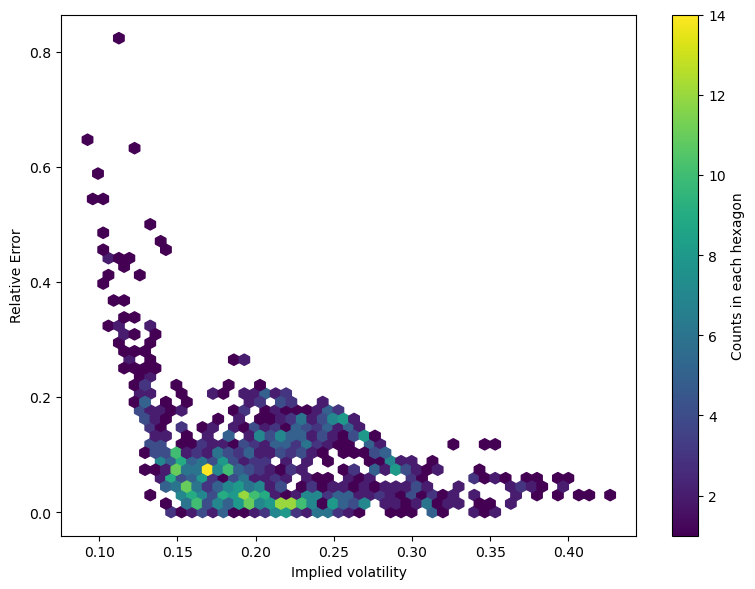

In [256]:
import matplotlib.pyplot as plt

x = plot_df["P_IV"]
y = plot_df["Relative Error"]

plt.figure(figsize=(8, 6))

# Create a hexagonal binning plot
hb = plt.hexbin(x, y, gridsize=50, mincnt=1)  # mincnt=1 hides empty bins

# Add a colorbar
cb = plt.colorbar(hb)
cb.set_label("Counts in each hexagon")

plt.xlabel("Implied volatility")
plt.ylabel("Relative Error")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# 1) Sort by strike so the line connects points in increasing strike order
df_sorted = plot_df.sort_values("strike")

# 2) Extract x and y
x = df_sorted["STRIKE"]
y = df_sorted["P_IV"]

# 3) Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker="o", linestyle="-", markersize=4)

# 4) Label axes
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (P_IV)")
plt.title("Volatility Skew: Implied Vol vs. Strike")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [258]:
plot_df['vol'] = 0.2
plot_df.head()

,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,...,risk_free_rate,implied_volatility,vol_20d_annual,Bjerksund_Stensland_price_const_vol,Bjerksund_Stensland_price_rolling_vol,Actual Price,Predicted Price,Absolute Error,Relative Error,vol
32187,2022-03-31,451.77,91.0,410.0,7.40,7.47,72 x 72,6.60,0.26096,13.0,...,0.0051,0.263243,0.225072,3.523957,4.892661,0.26096,0.269719,0.008759,0.033566,0.2
32188,2022-03-31,451.77,78.0,465.0,20.14,23.70,31 x 1,19.58,0.17140,1739.0,...,0.0051,0.173927,0.225072,23.537159,25.576202,0.17140,0.187531,0.016131,0.094116,0.2
32189,2022-03-31,451.77,91.0,405.0,5.19,6.72,10 x 156,5.56,0.25611,15.0,...,0.0051,0.257910,0.225072,2.753803,3.964308,0.25611,0.276675,0.020565,0.080298,0.2
32190,2022-03-31,451.77,78.0,470.0,23.44,26.55,10 x 1,25.00,0.16654,1275.0,...,0.0051,0.170051,0.225072,26.801419,28.777179,0.16654,0.184539,0.017999,0.108076,0.2
32191,2022-03-31,451.77,91.0,420.0,9.14,9.23,56 x 56,8.18,0.24703,11.0,...,0.0051,0.249231,0.225072,5.542334,7.218015,0.24703,0.256472,0.009442,0.038224,0.2


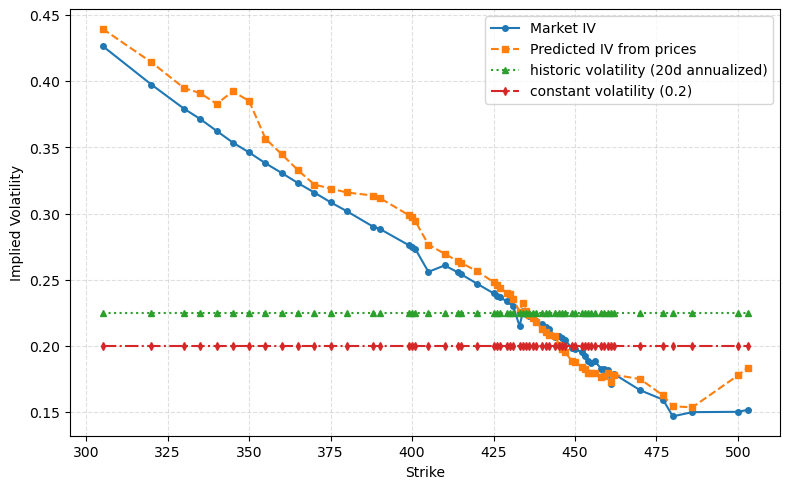

In [262]:
import matplotlib.pyplot as plt

# 1) Sort by strike so all curves connect in ascending-strike order
df_sorted = plot_df.sort_values("STRIKE")

# 2) Extract x and the four y-series
x      = df_sorted["STRIKE"]
y_true = df_sorted["P_IV"]            # market IV
y_pred = df_sorted["Predicted Price"]    # your first model
y_2    = df_sorted["vol_20d_annual"]  # second model column
y_3    = df_sorted["vol"]  # third model column

# 3) Create the figure
plt.figure(figsize=(8, 5))

# Plot each curve with its own style/label
plt.plot(
    x,
    y_true,
    marker="o",
    linestyle="-",
    markersize=4,
    label="Market IV"
)
plt.plot(
    x,
    y_pred,
    marker="s",
    linestyle="--",
    markersize=4,
    label="Predicted IV from prices"
)
plt.plot(
    x,
    y_2,
    marker="^",
    linestyle=":",
    markersize=4,
    label="historic volatility (20d annualized)"
)
plt.plot(
    x,
    y_3,
    marker="d",
    linestyle="-.",
    markersize=4,
    label="constant volatility (0.2)"
)

# 4) Labels, title, grid
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.grid(True, linestyle="--", alpha=0.4)

# 5) Legend to distinguish all four lines
plt.legend()

plt.tight_layout()
plt.show()


In [246]:
df_sorted.sort_values("STRIKE", inplace=True)
df_sorted.head()

,date,UNDERLYING_LAST,DTE,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_IV,P_VOLUME,...,risk_free_rate,implied_volatility,vol_20d_annual,Bjerksund_Stensland_price_const_vol,Bjerksund_Stensland_price_rolling_vol,Actual Price,Predicted Price,Absolute Error,Relative Error,vol
32717,2022-03-31,451.77,50.0,370.0,1.03,1.04,29 x 2103,0.96,0.32584,15430.0,...,0.0051,0.328878,0.225072,0.029536,0.086778,0.32584,0.366082,0.040242,0.123503,0.2
32718,2022-03-31,451.77,50.0,375.0,1.16,1.17,478 x 128,1.11,0.31580,157.0,...,0.0051,0.318574,0.225072,0.053258,0.140840,0.31580,0.339567,0.023767,0.075260,0.2
32719,2022-03-31,451.77,50.0,376.0,1.20,1.21,278 x 1395,1.06,0.31478,46.0,...,0.0051,0.317175,0.225072,0.059666,0.154641,0.31478,0.337174,0.022394,0.071143,0.2
32720,2022-03-31,451.77,50.0,377.0,1.23,1.24,378 x 344,1.02,0.31242,85.0,...,0.0051,0.315154,0.225072,0.066750,0.169607,0.31242,0.335611,0.023191,0.074231,0.2
32656,2022-03-31,451.77,50.0,378.0,1.27,1.28,150 x 1958,1.12,0.31122,460.0,...,0.0051,0.313630,0.225072,0.074573,0.185820,0.31122,0.336558,0.025338,0.081414,0.2


In [247]:
len(df_sorted)

105